# 10: Experiments and Results

All final experiments, quantitative comparisons, and figures for the report.
Every result in the thesis traces back to a cell in this notebook.

**Methods compared:**
- FBP — classical baseline
- TV — total-variation regularised reconstruction
- Fixed PnP-ADMM (σ=2, µ=20) — best fixed params from NB05 sensitivity sweep
- TFPnP (ours) — learned adaptive policy

**Metrics:** PSNR, SSIM, HaarPSI (Ander: "correlates most with doctor choice")

**Runs on CSD3** — requires trained checkpoint and LION operator.

## 1. Setup

The DRUNet denoiser used throughout was characterised separately in NB07 §15 —
PSNR gain across σ ∈ [1, 25], edge preservation, and per-image variation. This
notebook assumes a working denoiser and focuses on end-to-end reconstruction
comparisons against FBP, TV, and Fixed PnP-ADMM.

In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from collections import defaultdict
import math
import pandas as pd

import ct_tfpnp
from ct_tfpnp.models.policy import ResNetActor_ADMM
from ct_tfpnp.models.critic import ResNet_wobn
from ct_tfpnp.models.denoiser import DRUNetDenoiser
from ct_tfpnp.ct_ops.admm import ADMMStep
from ct_tfpnp.ct_ops.fbp import fbp as lion_fbp
from ct_tfpnp.evaluation.metrics import evaluate_reconstruction, psnr_np as psnr, ls_scale
from ct_tfpnp.datasets.lidc import get_lion_split, is_lung_slice
from ct_tfpnp.experiments.parallel_beam_ct import experiment
from ct_tfpnp.utils import read_metrics_config

from LION.CTtools.ct_utils import make_operator

# HaarPSI
try:
    from piq import haarpsi
    HAS_HAARPSI = True
    print("HaarPSI : available")
except ImportError:
    HAS_HAARPSI = False
    print("HaarPSI : not available — pip install piq")

device = torch.device("cuda")
print(f"ct_tfpnp : {ct_tfpnp.__version__}")
print(f"device   : {device}")
print(f"GPU      : {torch.cuda.get_device_name()}")

# set consistent plotting style for all notebook cells
plt.rcParams.update({
    "figure.dpi": 150,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "image.cmap": "gray",
    "image.interpolation": "nearest",
})

EXPERIMENT_NAME = "run_01_pat_20"
N_TRAIN_PATIENTS = 20  # how many patients were used for training

# create output directory for figures
output_dir = Path("../figures/10")
output_dir.mkdir(parents=True, exist_ok=True)

# create output directory for metrics
results_dir = Path(f"../results/metrics/{EXPERIMENT_NAME}")
results_dir.mkdir(parents=True, exist_ok=True)

# ── Geometry & operator ───────────────────────────────────────────────────
geo = experiment.experiment_params.geometry
op = make_operator(geo)
N_VIEWS = 30
NOISE_STD = 0.05

# ── DRUNet denoiser ───────────────────────────────────────────────────────
DENOISER_PATH = "/home/eaz21/rds/hpc-work/eaz21/results/baselines/drunet_gray.pth"
denoiser = DRUNetDenoiser(pretrained_path=DENOISER_PATH).to(device)
for p in denoiser.parameters():
    p.requires_grad_(False)
denoiser.eval()

admm_step = ADMMStep(op=op, denoiser=denoiser, n_x_steps=6)

# Uses LION's built-in split — consistent and reproducible
test_images, test_indices = get_lion_split(split="test", geometry=geo, device=device)

# Set to None for the full test set when running for the report.
N_TEST_SUBSET = 20
if N_TEST_SUBSET is not None:
    test_images = test_images[:N_TEST_SUBSET]
    test_indices = test_indices[:N_TEST_SUBSET]
    print(f"Test set subsetted to {N_TEST_SUBSET} images for fast evaluation")

test_labels = [f"test_{i}" for i in test_indices]

print(f"Test set: {len(test_images)} images (LION automatic split)")

# ── Metrics helper ────────────────────────────────────────────────────────
def to_4d(t):
    return t.unsqueeze(0) if t.dim() == 3 else t

def compute_metrics(gt, recon):
    """Wrapper around package evaluate_reconstruction for (1,H,W) tensors."""
    gt_4d = to_4d(gt)
    recon_4d = to_4d(recon)
    data_range = float(gt.max())
    # Clamp to [0, data_range] for HaarPSI compatibility
    recon_4d = recon_4d.clamp(0, data_range)
    return evaluate_reconstruction(recon_4d, gt_4d, data_range)

print("Setup complete.")

HaarPSI : available
ct_tfpnp : 0.1.dev7+g7644b2fc3.d20260613
device   : cuda
GPU      : NVIDIA A100-SXM4-80GB
Loaded DRUNet weights from /home/eaz21/rds/hpc-work/eaz21/results/baselines/drunet_gray.pth
Preparing patient list, this may take time....
Patient lists ready for test dataset
LION test split: 389 images, range [0.0000, 2.2075]
Test set subsetted to 20 images for fast evaluation
Test set: 20 images (LION automatic split)
Setup complete.


### Dataset

We use LION's built-in LIDC-IDRI split:
- **Train:** 3,300 slices (policy training — first 20 used for `run_01_pat_20`)
- **Validation:** 401 slices (first 10 used to select the best checkpoint each epoch)
- **Test:** 389 slices (all evaluation results reported on this held-out set)

In [2]:
from LION.data_loaders.LIDC_IDRI import LIDC_IDRI
for split in ["train", "validation", "test"]:
    ds = LIDC_IDRI(mode=split, geometry_parameters=geo)
    print(f"{split}: {len(ds)} images")

Preparing patient list, this may take time....
Patient lists ready for train dataset
train: 3300 images
Preparing patient list, this may take time....
Patient lists ready for validation dataset
validation: 401 images
Preparing patient list, this may take time....
Patient lists ready for test dataset
test: 389 images


## 2. Baseline Reconstructions

Run all methods on the test set and collect metrics.

In [3]:
NOISE_LEVELS = [0.05, 0.075, 0.10]
NOISE_LABELS = ['5%', '7.5%', '10%']
METHODS = ['FBP', 'TV', 'Fixed PnP-ADMM', 'TFPnP']

all_results = {nl: {m: [] for m in METHODS} for nl in NOISE_LEVELS}

# Auto-find best checkpoint
ckpt_dir = Path(f"../results/learned/{EXPERIMENT_NAME}")

# Priority 1: validation-best checkpoint (saved by our training loop)
ckpt_val = ckpt_dir / "checkpoint_best_val.pth"
# Priority 2: notebook-style best checkpoint
ckpt_best = ckpt_dir / "checkpoint_best.pth"
# Priority 3: latest LION checkpoint (highest epoch number)
lion_ckpts = sorted(ckpt_dir.glob("tfpnp_check_*.pt"))

if ckpt_val.exists():
    ckpt = torch.load(ckpt_val, map_location=device, weights_only=False)
    epoch = ckpt.get('epoch', '?')
    val_p = ckpt.get('val_psnr', ckpt.get('mean_psnr', 0))
    train_p = ckpt.get('train_psnr', ckpt.get('mean_psnr', 0))
    print(f"Loaded validation-best: epoch {epoch}, val={val_p:.2f} dB, train={train_p:.2f} dB")
elif ckpt_best.exists():
    ckpt = torch.load(ckpt_best, map_location=device, weights_only=False)
    print(f"Loaded best checkpoint: epoch {ckpt['epoch']}, PSNR={ckpt['mean_psnr']:.2f} dB")
elif lion_ckpts:
    ckpt = torch.load(lion_ckpts[-1], map_location=device, weights_only=False)
    print(f"Loaded LION checkpoint: {lion_ckpts[-1].name} (epoch {ckpt['epoch']})")
else:
    raise FileNotFoundError(f"No checkpoints found in {ckpt_dir}")

cfg = read_metrics_config(ckpt_dir)
sigma_range = tuple(cfg.get('sigma_range') or (1.0, 5.0))
mu_range = tuple(cfg.get('mu_range') or (10.0, 100.0))
print(f"Loaded ranges: σ∈{sigma_range}, µ∈{mu_range}")
print(f"Loaded ranges: σ∈{sigma_range}, µ∈{mu_range}")

# Load policy from checkpoint — handle both formats
if 'model_state_dict' in ckpt:
    # LION/TFPnPSolver format
    from ct_tfpnp.models.tfpnp_model import TFPnPModel
    model_params = TFPnPModel.default_parameters()
    model_params.sigma_min, model_params.sigma_max = sigma_range
    model_params.mu_min, model_params.mu_max = mu_range
    model = TFPnPModel(model_parameters=model_params, geometry=geo)
    model.load_state_dict(ckpt['model_state_dict'])
    policy_best = model.policy.to(device).eval()
elif 'policy_state_dict' in ckpt:
    # Notebook format
    policy_best = ResNetActor_ADMM(in_channels=5, n_action_steps=5,
                                    sigma_range=sigma_range,
                                    mu_range=mu_range).to(device)
    policy_best.load_state_dict(ckpt['policy_state_dict'])
    policy_best.eval()
else:
    raise KeyError(f"Checkpoint has unknown format. Keys: {list(ckpt.keys())}")

print(f"Policy loaded: σ∈[{policy_best.sigma_min}, {policy_best.sigma_max}], "
      f"µ∈[{policy_best.mu_min}, {policy_best.mu_max}]")

from ct_tfpnp.ct_ops.tv import tv_reconstruction

for noise_frac, noise_label in zip(NOISE_LEVELS, NOISE_LABELS):
    print(f"\n{'='*60}")
    print(f"Noise level: {noise_label}")
    print(f"{'='*60}")

    for img_idx, gt in enumerate(test_images):
        # Generate sinogram with this noise level
        sino_clean = op.forward(gt)
        SCALE = sino_clean.max() / gt.max()
        torch.manual_seed(img_idx * 100)  # same seed per image across noise levels
        sino_noisy = sino_clean / SCALE + noise_frac * (sino_clean / SCALE).std() * torch.randn_like(sino_clean)
        y = sino_noisy * SCALE

        # ── FBP ───────────────────────────────────────────────────
        x_fbp = lion_fbp(y, op)
        x_fbp = ls_scale(gt, x_fbp).clamp(min=0)
        all_results[noise_frac]['FBP'].append(compute_metrics(gt, x_fbp))

        # ── TV ────────────────────────────────────────────────────
        x_tv = tv_reconstruction(y, op, x0=x_fbp, lam=0.01, n_iters=200)
        x_tv_scaled = ls_scale(gt, x_tv).clamp(min=0)
        all_results[noise_frac]['TV'].append(compute_metrics(gt, x_tv_scaled))

        # ── Fixed PnP-ADMM (σ=1.5, μ=20) ───────────────────────────
        x, z, u = x_fbp.clone(), x_fbp.clone(), torch.zeros_like(x_fbp)
        with torch.no_grad():
            for k in range(20):
                x, z, u = admm_step(x, z, u, y, sigma=1.5, mu=20.0)
        x_fix = ls_scale(gt, x).clamp(min=0)
        all_results[noise_frac]['Fixed PnP-ADMM'].append(compute_metrics(gt, x_fix))


        # ── TFPnP (learned policy) ───────────────────────────────
        if policy_best is not None:
            x, z, u = x_fbp.clone(), x_fbp.clone(), torch.zeros_like(x_fbp)
            noise_level = torch.tensor([noise_frac], device=device)
            with torch.no_grad():
                for t in range(6):
                    iter_frac = torch.tensor([t / 6.0], device=device)
                    stop_logits, sigma_seq, mu_seq = policy_best(
                        to_4d(x), to_4d(z), to_4d(u), noise_level, iter_frac)
                    stop_prob = F.softmax(stop_logits, dim=-1)[0, 1].item()
                    if t > 0 and stop_prob > 0.5:
                        break
                    for i in range(5):
                        x, z, u = admm_step(x, z, u, y,
                                             sigma=sigma_seq[0, i], mu=mu_seq[0, i])
            x_tfpnp = ls_scale(gt, x).clamp(min=0)
            all_results[noise_frac]['TFPnP'].append(compute_metrics(gt, x_tfpnp))
        else:
            all_results[noise_frac]['TFPnP'].append(
                {'psnr': float('nan'), 'ssim': float('nan'), 'haarpsi': float('nan')})

        print(f"  {test_labels[img_idx]}: "
              f"FBP={all_results[noise_frac]['FBP'][-1]['psnr']:.1f} | "
              f"TV={all_results[noise_frac]['TV'][-1]['psnr']:.1f} | "
              f"Fixed={all_results[noise_frac]['Fixed PnP-ADMM'][-1]['psnr']:.1f} | "
              f"TFPnP={all_results[noise_frac]['TFPnP'][-1]['psnr']:.1f}")

print("\nDone.")

Loaded validation-best: epoch 19, val=26.80 dB, train=26.21 dB
Loaded ranges: σ∈(1.0, 5.0), µ∈(10.0, 100.0)
Loaded ranges: σ∈(1.0, 5.0), µ∈(10.0, 100.0)
Policy loaded: σ∈[1.0, 5.0], µ∈[10.0, 100.0]

Noise level: 5%


/rds/user/eaz21/hpc-work/projects/tomosipo/tomosipo/links/torch.py:63: UserWarning: The parameter initial_value should be contiguous. It has been automatically made contiguous. Use `ts.link(x.contiguous())' to inhibit this warning. 
  warnings.warn(


  test_0: FBP=12.2 | TV=18.3 | Fixed=23.4 | TFPnP=28.8
  test_1: FBP=13.2 | TV=18.4 | Fixed=23.7 | TFPnP=27.1
  test_2: FBP=13.3 | TV=18.4 | Fixed=23.3 | TFPnP=26.8
  test_3: FBP=20.9 | TV=26.4 | Fixed=32.3 | TFPnP=32.7
  test_4: FBP=21.2 | TV=27.1 | Fixed=33.5 | TFPnP=34.0
  test_5: FBP=11.5 | TV=16.0 | Fixed=20.6 | TFPnP=25.5
  test_6: FBP=15.0 | TV=19.9 | Fixed=24.6 | TFPnP=26.8
  test_7: FBP=14.5 | TV=19.1 | Fixed=24.2 | TFPnP=26.0
  test_8: FBP=14.5 | TV=19.4 | Fixed=24.8 | TFPnP=26.6
  test_9: FBP=13.5 | TV=18.3 | Fixed=25.2 | TFPnP=26.9
  test_10: FBP=11.4 | TV=17.3 | Fixed=20.0 | TFPnP=25.8
  test_11: FBP=11.8 | TV=17.7 | Fixed=20.8 | TFPnP=25.5
  test_12: FBP=13.3 | TV=18.6 | Fixed=23.2 | TFPnP=25.9
  test_13: FBP=14.0 | TV=19.3 | Fixed=24.3 | TFPnP=26.2
  test_14: FBP=14.4 | TV=20.4 | Fixed=25.3 | TFPnP=26.9
  test_15: FBP=15.2 | TV=21.1 | Fixed=25.1 | TFPnP=29.3
  test_16: FBP=17.3 | TV=22.2 | Fixed=27.2 | TFPnP=28.8
  test_17: FBP=19.2 | TV=23.9 | Fixed=29.0 | TFPnP=29.7
  

## 3. Results Table

In [4]:
# Print results per noise level
for noise_frac, noise_label in zip(NOISE_LEVELS, NOISE_LABELS):
    print(f"\n{'='*60}")
    print(f"Noise level: {noise_label}")
    print(f"{'='*60}")
    print(f"{'Method':<22} {'PSNR (dB)':<14} {'SSIM':<14} {'HaarPSI':<14}")
    print("-" * 64)

    for method in METHODS:
        psnrs = [r['psnr'] for r in all_results[noise_frac][method]]
        ssims = [r['ssim'] for r in all_results[noise_frac][method]]
        hp_str = ""
        if HAS_HAARPSI and 'haarpsi' in all_results[noise_frac][method][0]:
            hps = [r['haarpsi'] for r in all_results[noise_frac][method]]
            hp_str = f"{np.mean(hps):.4f}±{np.std(hps):.4f}"
        print(f"{method:<22} {np.mean(psnrs):.2f}±{np.std(psnrs):.2f}    "
              f"{np.mean(ssims):.4f}±{np.std(ssims):.4f}  {hp_str}")

# Compact PSNR-only table matching paper Table 5 format
print(f"\n{'='*60}")
print("PSNR Summary (matching paper Table 5 format)")
print(f"{'='*60}")
print(f"{'Method':<22}", end="")
for label in NOISE_LABELS:
    print(f"  {label:>12}", end="")
print()
print("-" * 60)
for method in METHODS:
    print(f"{method:<22}", end="")
    for nl in NOISE_LEVELS:
        psnrs = [r['psnr'] for r in all_results[nl][method]]
        print(f"  {np.mean(psnrs):>5.2f}±{np.std(psnrs):.2f}", end="")
    print()

print(f"\nPaper reference (Table 5):")
print(f"{'FBP':<22}  18.37        16.16        14.32")
print(f"{'TV':<22}  21.47        19.17        16.95")
print(f"{'TFPnP (paper)':<22}  24.50        24.23        23.72")

# Save all results to CSV
rows = []
for nl, label in zip(NOISE_LEVELS, NOISE_LABELS):
    for method in METHODS:
        row = {'noise_level': label, 'method': method}
        row['psnr_mean'] = np.mean([r['psnr'] for r in all_results[nl][method]])
        row['psnr_std'] = np.std([r['psnr'] for r in all_results[nl][method]])
        row['ssim_mean'] = np.mean([r['ssim'] for r in all_results[nl][method]])
        row['ssim_std'] = np.std([r['ssim'] for r in all_results[nl][method]])
        if HAS_HAARPSI and 'haarpsi' in all_results[nl][method][0]:
            row['haarpsi_mean'] = np.mean([r['haarpsi'] for r in all_results[nl][method]])
            row['haarpsi_std'] = np.std([r['haarpsi'] for r in all_results[nl][method]])
        rows.append(row)

pd.DataFrame(rows).to_csv(results_dir / "all_results.csv", index=False, float_format="%.4f")
print(f"\nSaved to {results_dir / 'all_results.csv'}")


Noise level: 5%
Method                 PSNR (dB)      SSIM           HaarPSI       
----------------------------------------------------------------
FBP                    15.22±3.02    0.0866±0.0460  0.2422±0.0437
TV                     20.45±2.99    0.3192±0.0989  0.3955±0.0481
Fixed PnP-ADMM         25.46±3.57    0.5618±0.1615  0.4311±0.0719
TFPnP                  27.96±2.33    0.7804±0.0729  0.4704±0.0364

Noise level: 7.5%
Method                 PSNR (dB)      SSIM           HaarPSI       
----------------------------------------------------------------
FBP                    14.27±2.93    0.0697±0.0392  0.2332±0.0417
TV                     19.06±2.99    0.2834±0.1056  0.3510±0.0509
Fixed PnP-ADMM         23.44±3.04    0.4457±0.1459  0.3559±0.0532
TFPnP                  26.68±2.27    0.7505±0.0712  0.4015±0.0331

Noise level: 10%
Method                 PSNR (dB)      SSIM           HaarPSI       
----------------------------------------------------------------
FBP                

## 4. Result visualisations

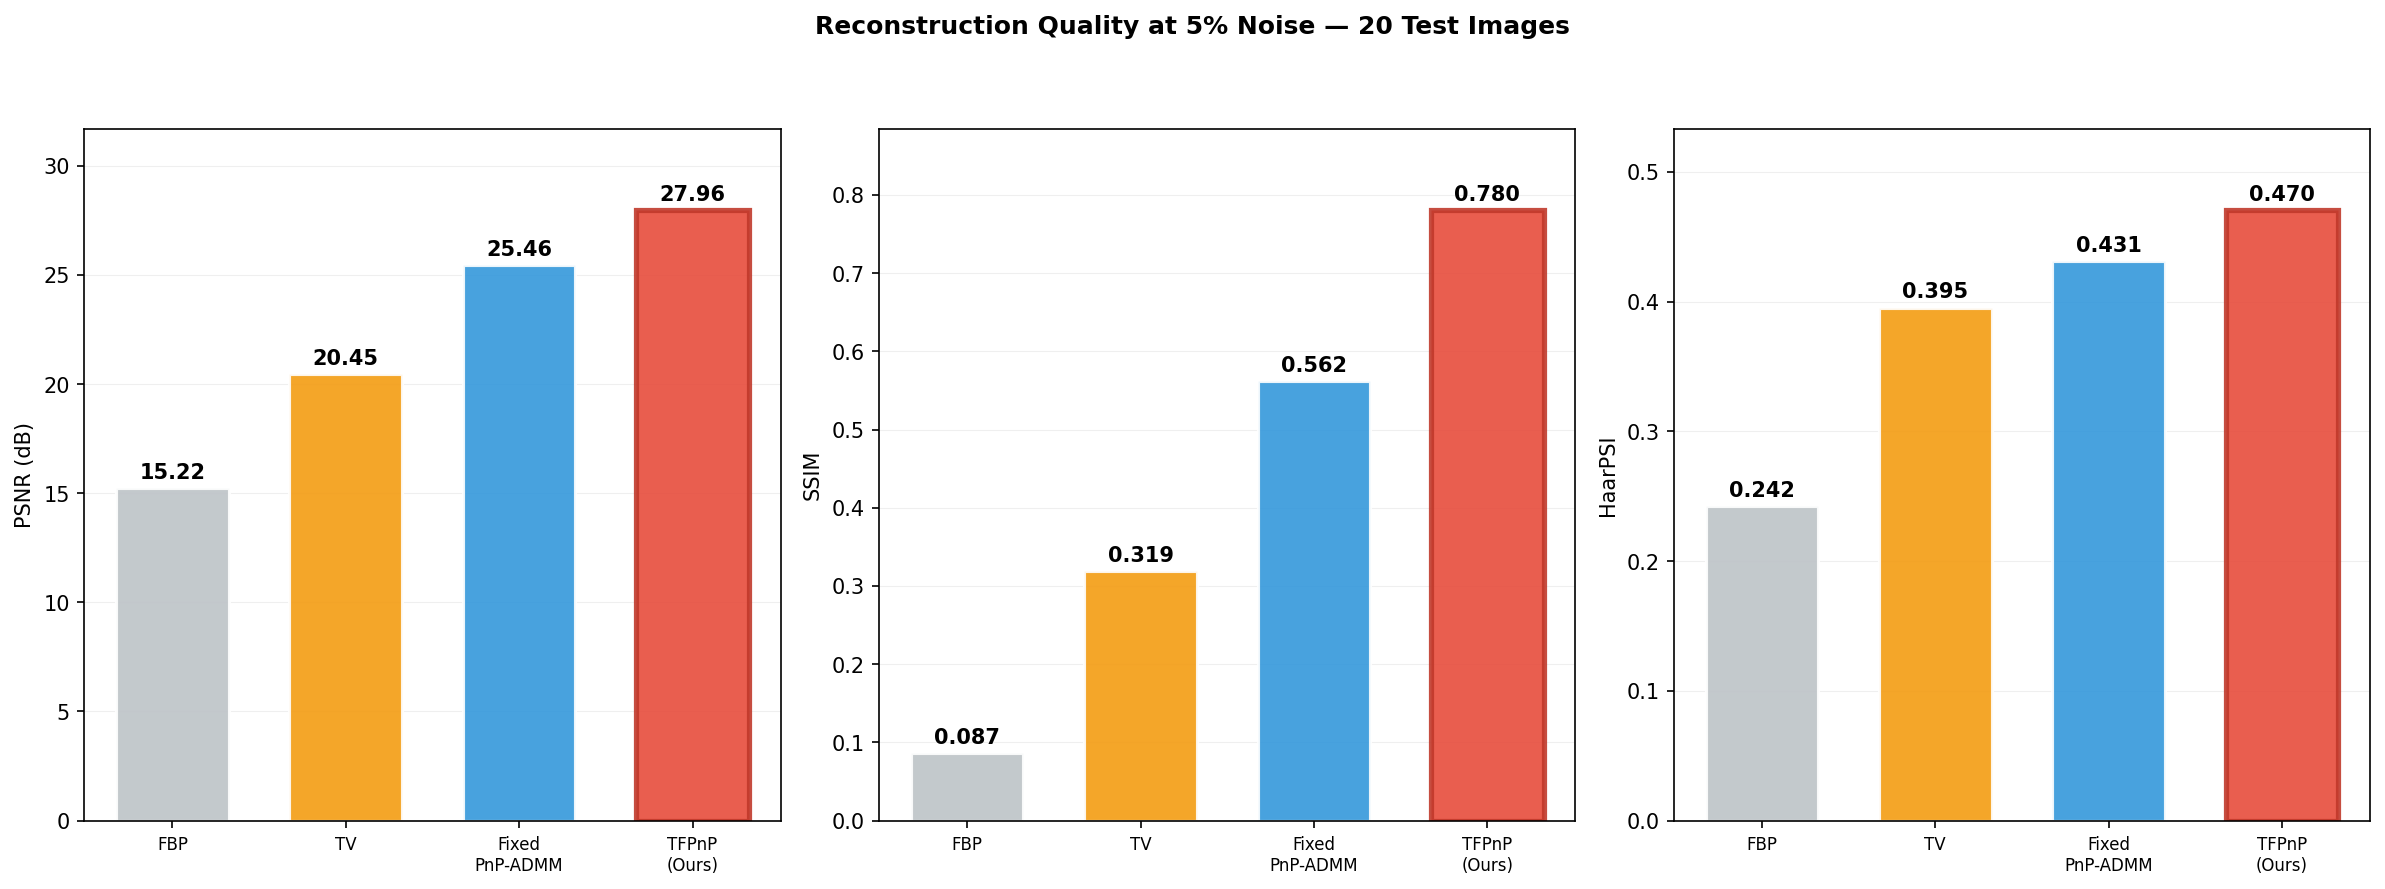

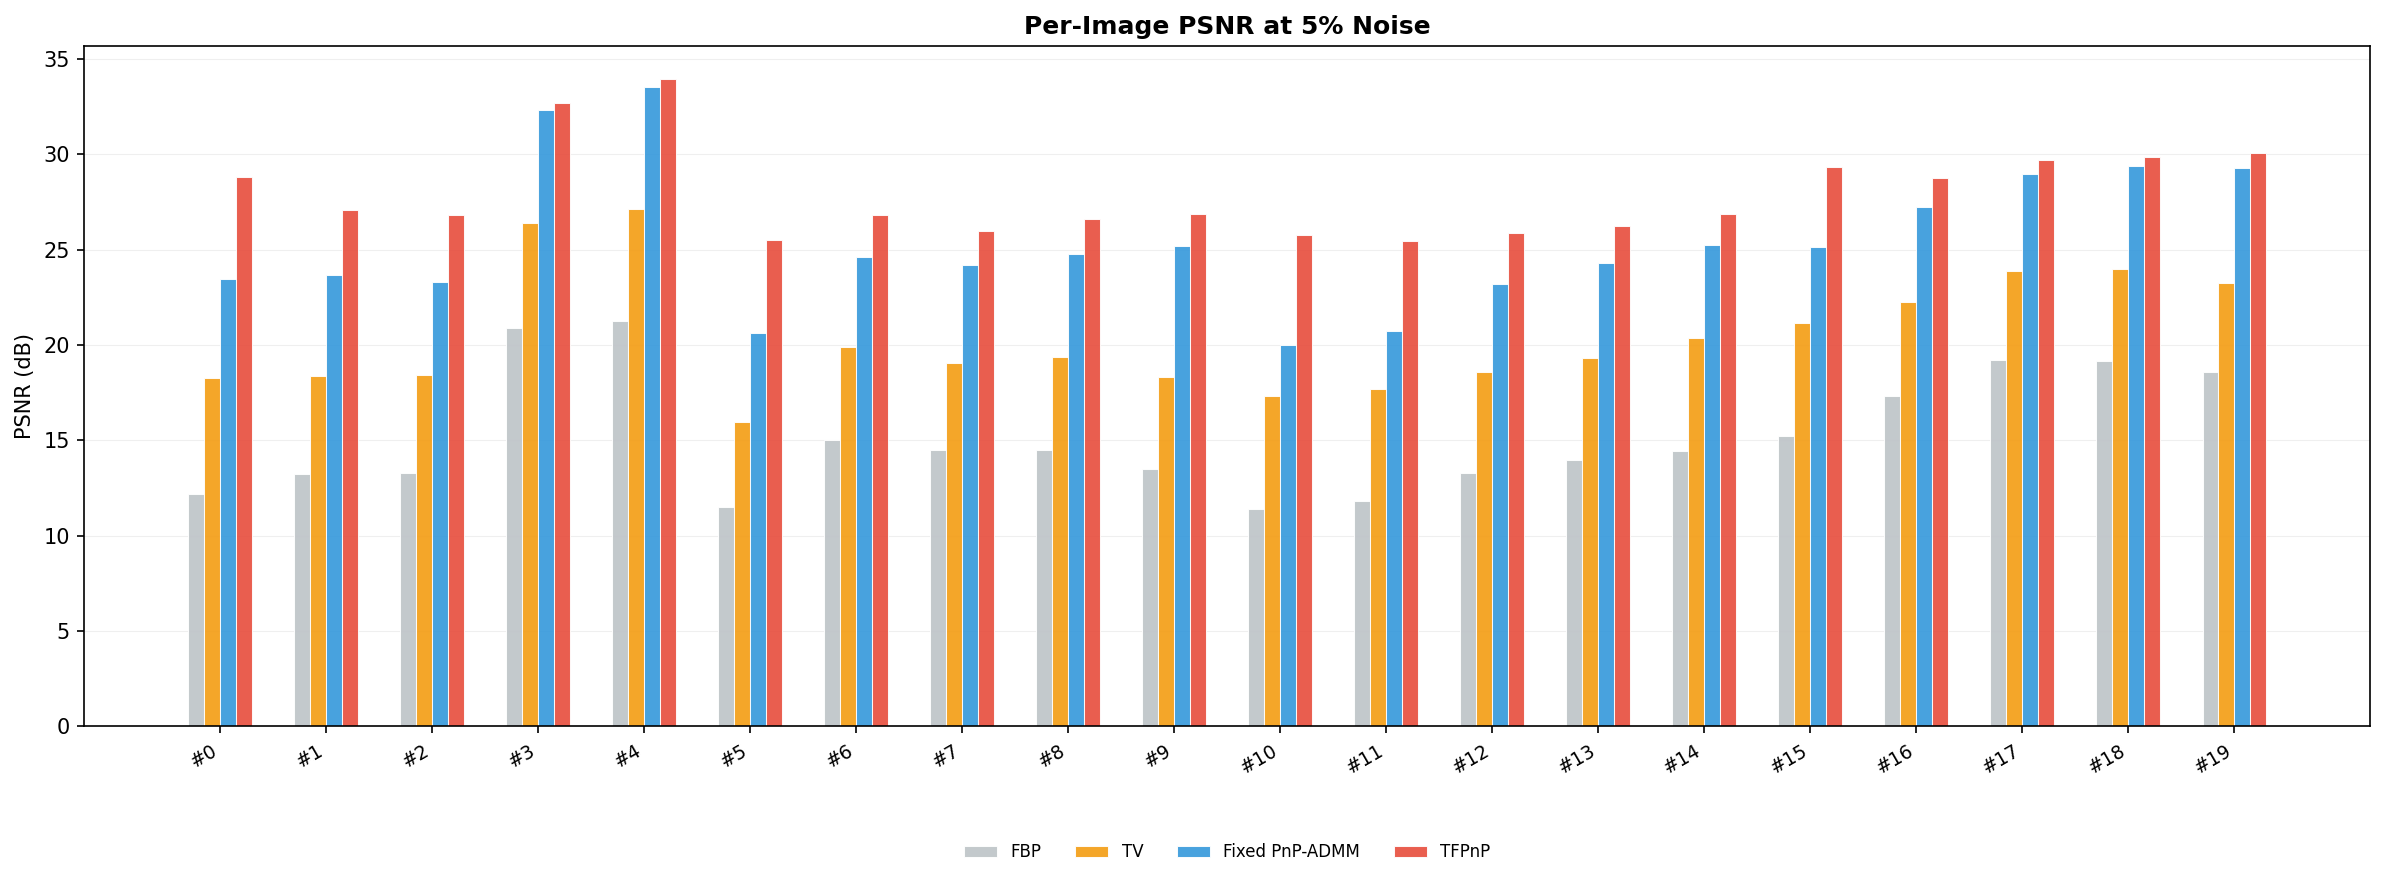

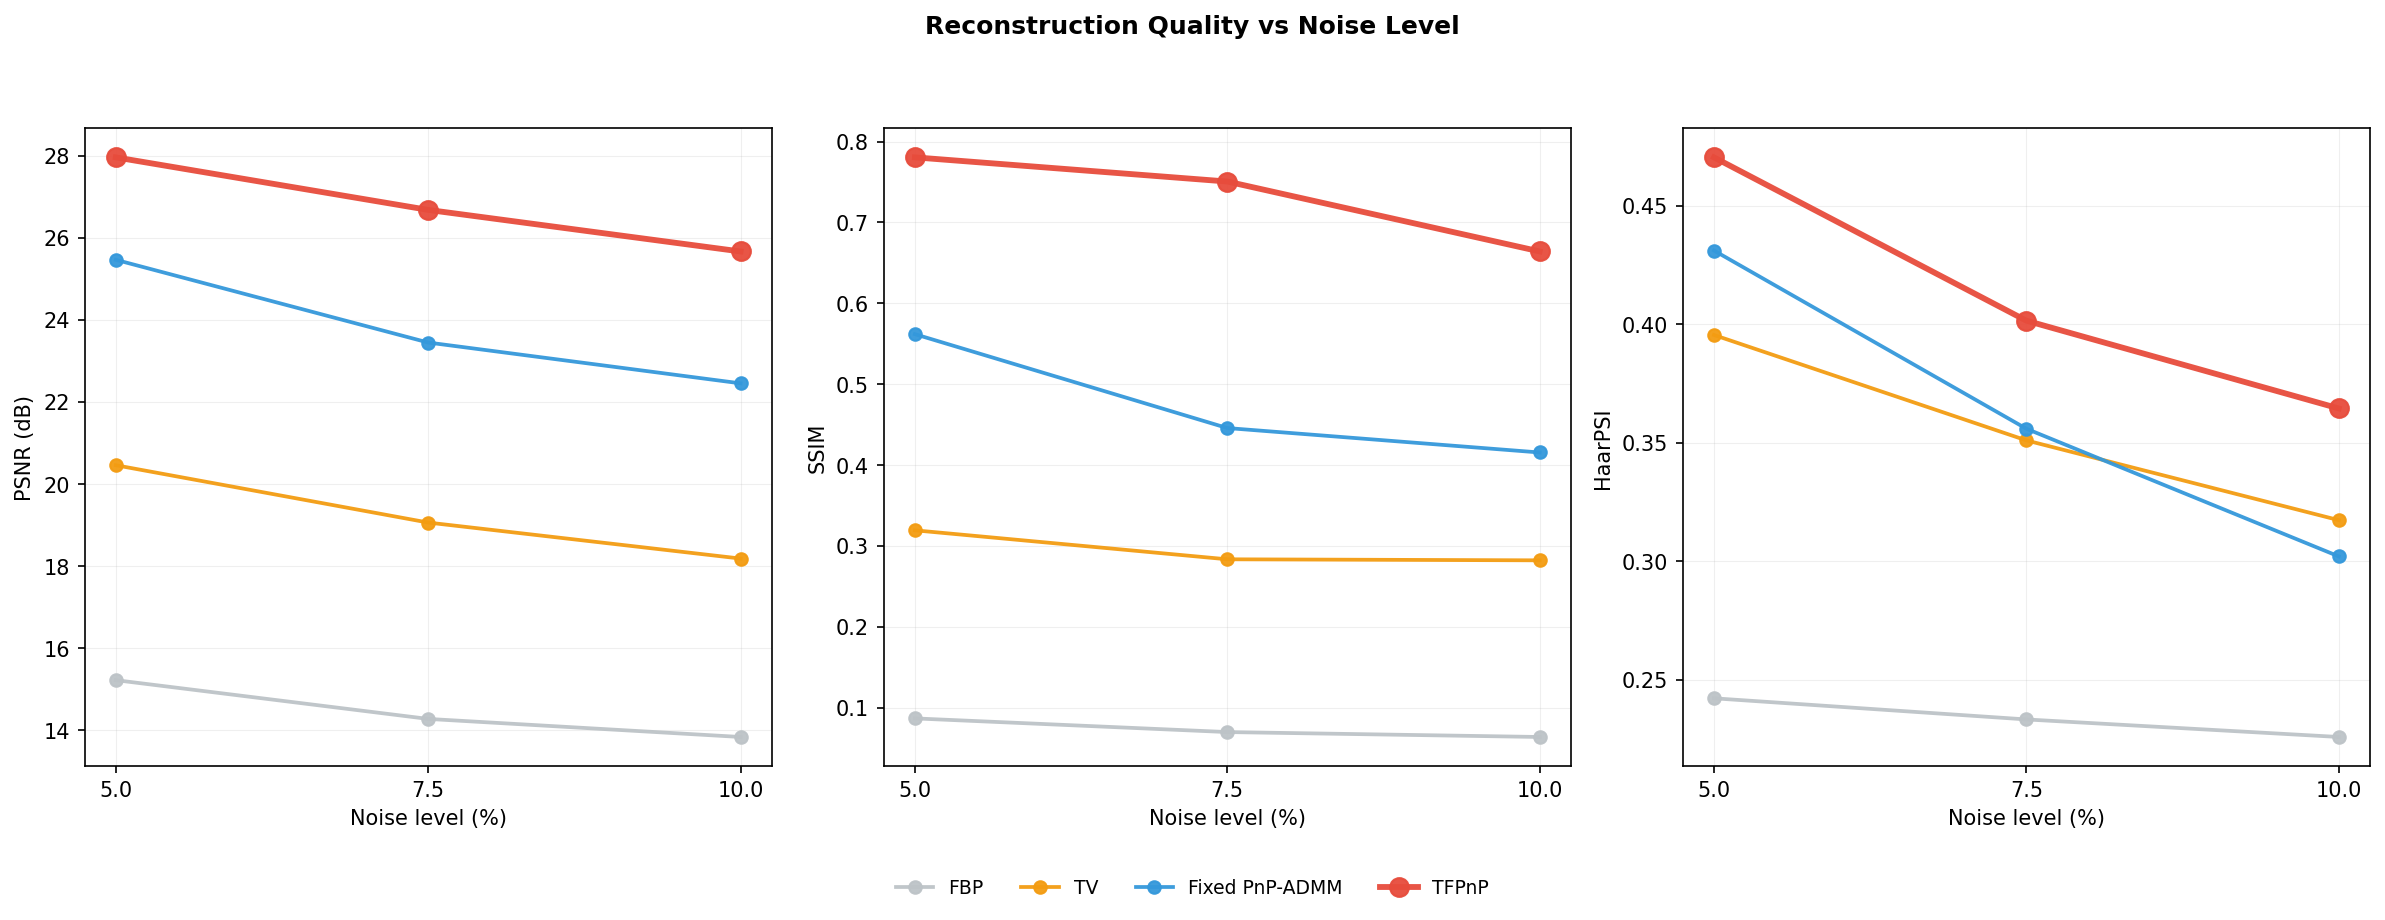

In [5]:
import pandas as pd

METHODS = ['FBP', 'TV', 'Fixed PnP-ADMM', 'TFPnP']
method_labels = ['FBP', 'TV', 'Fixed\nPnP-ADMM', 'TFPnP\n(Ours)']
colors = ['#bdc3c7', '#f39c12', '#3498db', '#e74c3c'] 
metrics_names = ['psnr', 'ssim', 'haarpsi']
metric_labels = ['PSNR (dB)', 'SSIM', 'HaarPSI']

# Use 5% noise results for the main comparison
noise_show = 0.05
results_5pct = all_results[noise_show]

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 1: Bar chart — PSNR / SSIM / HaarPSI at 5% noise
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, metric, ylabel in zip(axes, metrics_names, metric_labels):
    means = [np.mean([r[metric] for r in results_5pct[m]]) for m in METHODS]

    bars = ax.bar(range(len(METHODS)), means,
                  color=colors, alpha=0.9,
                  edgecolor='white', linewidth=1.5, width=0.65)

    # Highlight TFPnP
    bars[-1].set_edgecolor('#c0392b')
    bars[-1].set_linewidth(2.5)

    ax.set_xticks(range(len(METHODS)))
    ax.set_xticklabels(method_labels, fontsize=8)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.grid(axis='y', alpha=0.2, linewidth=0.5)
    ax.set_axisbelow(True)

    # Value labels sitting just above each bar — no error bars
    fmt = '.2f' if metric == 'psnr' else '.3f'
    for i, m in enumerate(means):
        offset = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.015
        ax.text(i, m + offset, f'{m:{fmt}}', ha='center',
                fontsize=10, fontweight='bold')

    ax.set_ylim(bottom=0)
    ax.set_ylim(top=ax.get_ylim()[1] * 1.08)   # headroom for labels

plt.suptitle(f'Reconstruction Quality at 5% Noise — {len(test_images)} Test Images',
             fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(output_dir / "01_metrics_comparison.pdf", bbox_inches="tight")
plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 2: Per-image PSNR comparison at 5% noise (auto-subsamples if >30)
# ═══════════════════════════════════════════════════════════════════════════
n_test = len(test_labels)

if n_test > 30:
    n_show = max(30, int(np.ceil(0.1 * n_test)))
    show_indices = np.linspace(0, n_test - 1, n_show, dtype=int)
else:
    show_indices = np.arange(n_test)

fig, ax = plt.subplots(figsize=(16, 6))
x_pos = np.arange(len(show_indices))
n_methods = len(METHODS)
width = 0.15
offset = (n_methods - 1) * width / 2

for i, (method, color, label) in enumerate(zip(METHODS, colors, method_labels)):
    psnrs = [results_5pct[method][idx]['psnr'] for idx in show_indices]
    ax.bar(x_pos + i * width - offset, psnrs, width,
           label=method, color=color, alpha=0.9,
           edgecolor='white', linewidth=0.5)

labels_subset = [test_labels[idx].replace('test_', '#') for idx in show_indices]
ax.set_xticks(x_pos)
ax.set_xticklabels(labels_subset, rotation=30, ha='right', fontsize=9)

if n_test > 30:
    title = (f'Per-Image PSNR at 5% Noise '
             f'({len(show_indices)} of {n_test} images, evenly spaced)')
else:
    title = 'Per-Image PSNR at 5% Noise'

ax.set_ylabel('PSNR (dB)', fontsize=10)
ax.set_title(title, fontsize=12, fontweight='bold')
ax.legend(fontsize=8, ncol=n_methods, loc='upper center',
          bbox_to_anchor=(0.5, -0.15), frameon=False)
ax.grid(axis='y', alpha=0.2, linewidth=0.5)
ax.set_axisbelow(True)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig(output_dir / "02_per_image_psnr.pdf", bbox_inches="tight")
plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 3: PSNR vs noise level (like paper Table 5 but as a line plot)
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
noise_pcts = np.array([5, 7.5, 10])

for ax, metric, ylabel in zip(axes, metrics_names, metric_labels):
    for method, color in zip(METHODS, colors):
        means = [np.mean([r[metric] for r in all_results[nl][method]]) for nl in NOISE_LEVELS]
        lw = 2.8 if method == 'TFPnP' else 1.8
        ms = 9   if method == 'TFPnP' else 6
        ax.plot(noise_pcts, means, marker='o', lw=lw, ms=ms,
                color=color, label=method, alpha=0.95)

    ax.set_xlabel('Noise level (%)', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xticks(noise_pcts)
    ax.grid(True, alpha=0.2, linewidth=0.5)
    ax.set_axisbelow(True)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(METHODS),
           bbox_to_anchor=(0.5, -0.02), frameon=False, fontsize=9)

plt.suptitle('Reconstruction Quality vs Noise Level', fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 0.93])
plt.savefig(output_dir / "03_metrics_vs_noise.pdf", bbox_inches="tight")
plt.show()

## 5. Policy Behaviour Visualisation

For several representative validation images, plot the σ and µ trajectories
that the trained policy chooses across its ADMM iterations. Replicates Figure 8
of Wei et al. (2022).

Preparing patient list, this may take time....
Patient lists ready for validation dataset
LION validation split: 401 images, range [0.0000, 2.3958]
m, N = 5, 6 (from metrics_history.json)
Selected val indices: [2, 100, 201, 301, 400]


/rds/user/eaz21/hpc-work/projects/tomosipo/tomosipo/links/torch.py:63: UserWarning: The parameter initial_value should be contiguous. It has been automatically made contiguous. Use `ts.link(x.contiguous())' to inhibit this warning. 
  warnings.warn(


  Val #2: 6 decisions, FBP=14.3 → TFPnP=27.0 dB
  Val #100: 6 decisions, FBP=14.8 → TFPnP=27.1 dB
  Val #201: 6 decisions, FBP=14.4 → TFPnP=26.2 dB
  Val #301: 6 decisions, FBP=15.0 → TFPnP=21.5 dB
  Val #400: 6 decisions, FBP=15.3 → TFPnP=26.5 dB


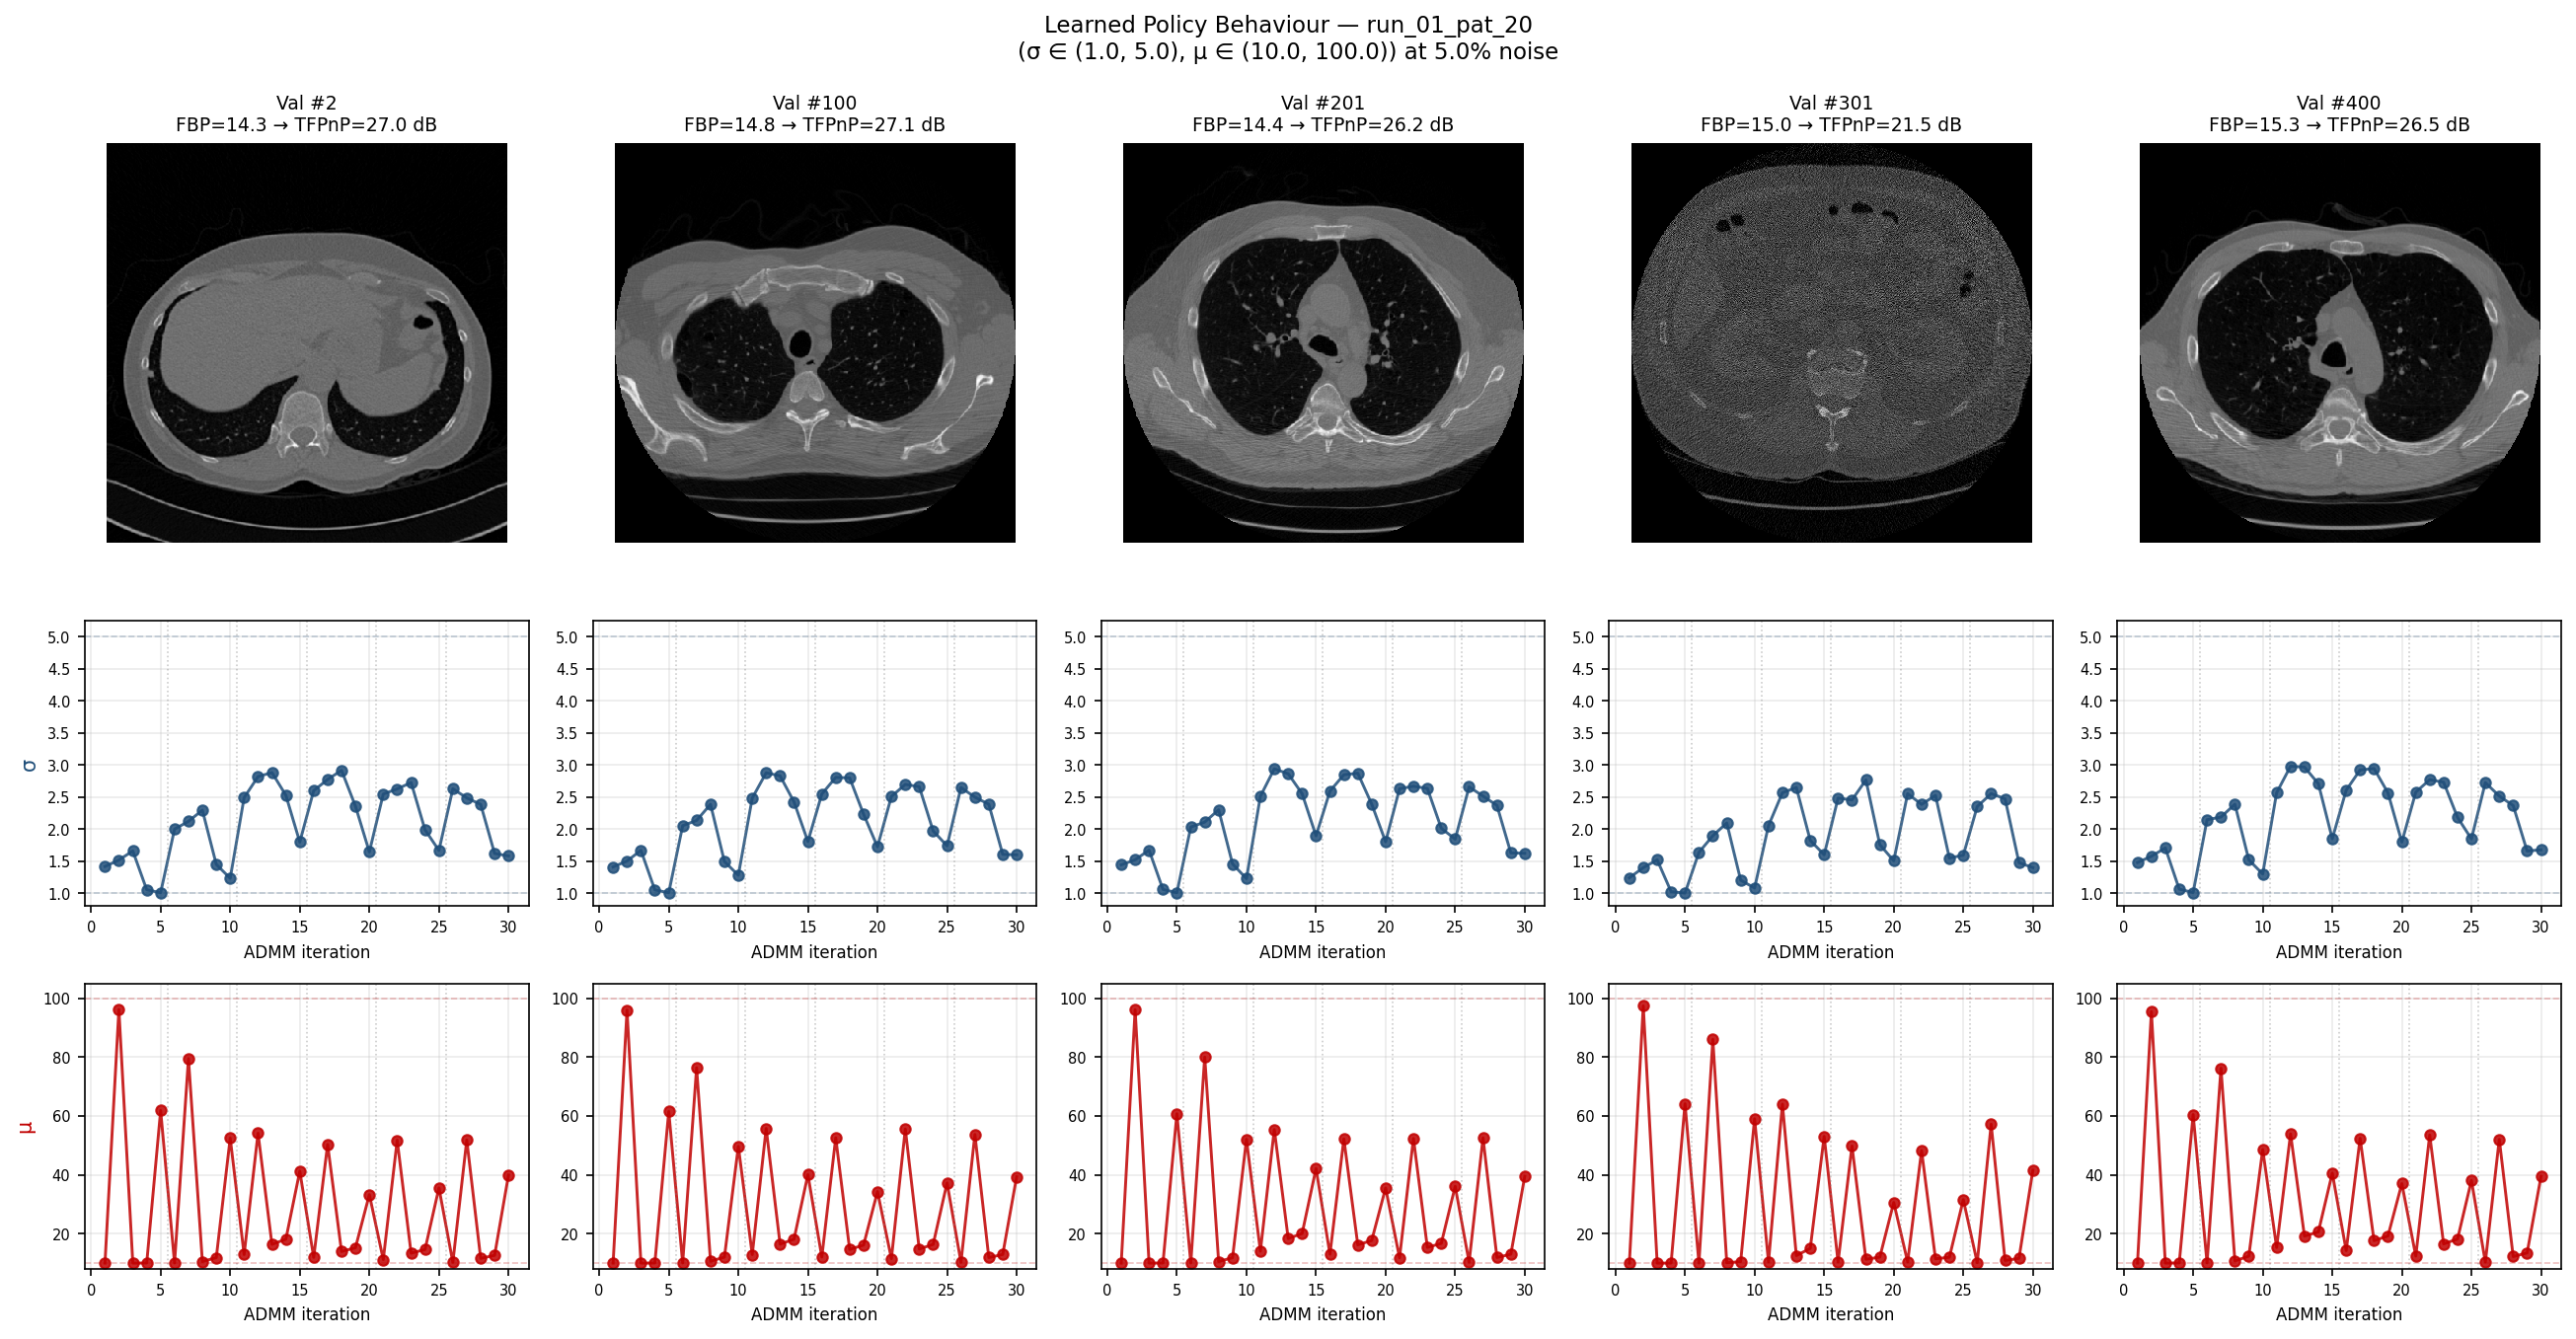

In [6]:
# ═══════════════════════════════════════════════════════════════════════════
# Helper functions (moved to scripts/plot_policy_behaviour.py after development)
# ═══════════════════════════════════════════════════════════════════════════
    
def _run_tfpnp_recording(policy, admm_step, gt, op, noise_std, device, m, N, seed=99):
    """Run TFPnP on one image, recording every σ and µ chosen. Returns dict."""
    sino_clean = op.forward(gt)
    SCALE = sino_clean.max() / gt.max()
    torch.manual_seed(seed)
    sino_scaled = sino_clean / SCALE
    noise = noise_std * sino_scaled.std() * torch.randn_like(sino_scaled)
    y = (sino_scaled + noise) * SCALE

    x_fbp = lion_fbp(y, op)
    x_fbp = ls_scale(gt, x_fbp).clamp(min=0)
    fbp_psnr = psnr(gt, x_fbp)

    x, z, u = x_fbp.clone(), x_fbp.clone(), torch.zeros_like(x_fbp)
    noise_level = torch.tensor([noise_std], device=device)
    all_sigma, all_mu, n_decisions = [], [], 0

    with torch.no_grad():
        for t in range(N):
            iter_frac = torch.tensor([t / N], device=device)
            stop_logits, sigma_seq, mu_seq = policy(
                to_4d(x), to_4d(z), to_4d(u), noise_level, iter_frac)
            if t > 0 and F.softmax(stop_logits, -1)[0, 1].item() > 0.5:
                break
            all_sigma.extend(sigma_seq[0].tolist())
            all_mu.extend(mu_seq[0].tolist())
            n_decisions += 1
            for i in range(m):
                x, z, u = admm_step(x, z, u, y,
                                    sigma=sigma_seq[0, i], mu=mu_seq[0, i])

    x_final = ls_scale(gt, x).clamp(min=0)
    return {
        'gt': gt, 'x_fbp': x_fbp, 'x_final': x_final,
        'sigmas': all_sigma, 'mus': all_mu,
        'n_decisions': n_decisions,
        'fbp_psnr': fbp_psnr, 'final_psnr': psnr(gt, x_final),
    }


# ═══════════════════════════════════════════════════════════════════════════
# Main: collect data and plot
# ═══════════════════════════════════════════════════════════════════════════

# Configuration
N_BEHAVIOUR_IMAGES = 5
BEHAVIOUR_NOISE = 0.05
SIGMA_COLOR = '#1F4E79'
MU_COLOR = '#C00000'

# Load validation images
val_images, _ = get_lion_split("validation", geometry=geo, device=device)

# σ/µ ranges from policy attributes; m, N from checkpoint config
sigma_range = policy_best.sigma_range
mu_range = policy_best.mu_range

cfg = read_metrics_config(ckpt_dir)
m_admm = int(cfg.get('m', 5))
N_decisions = int(cfg.get('N', 6))
print(f"m, N = {m_admm}, {N_decisions} (from metrics_history.json)")

# Select images
lung_indices = [i for i, img in enumerate(val_images) if is_lung_slice(img)]
chosen_positions = np.linspace(0, len(lung_indices) - 1, N_BEHAVIOUR_IMAGES, dtype=int)
selected_indices = [lung_indices[p] for p in chosen_positions]
print(f"Selected val indices: {selected_indices}")

# Collect σ/µ trajectories for each selected image
all_data = []
for idx in selected_indices:
    data = _run_tfpnp_recording(policy_best, admm_step, val_images[idx], op,
                                BEHAVIOUR_NOISE, device, m_admm, N_decisions)
    data['idx'] = idx
    all_data.append(data)
    print(f"  Val #{idx}: {data['n_decisions']} decisions, "
          f"FBP={data['fbp_psnr']:.1f} → TFPnP={data['final_psnr']:.1f} dB")

# ── Plot 3×N grid ─────────────────────────────────────────────────────
n = len(all_data)
fig, axes = plt.subplots(3, n, figsize=(3.5 * n, 9),
                         gridspec_kw={'height_ratios': [1.4, 1, 1]})
if n == 1:
    axes = axes.reshape(3, 1)

for col, data in enumerate(all_data):
    # Row 1: ground truth
    ax = axes[0, col]
    gt_np = data['gt'][0].cpu().numpy()
    ax.imshow(gt_np, cmap='gray', vmin=gt_np.min(), vmax=gt_np.max())
    ax.set_title(f"Val #{data['idx']}\n"
                 f"FBP={data['fbp_psnr']:.1f} → TFPnP={data['final_psnr']:.1f} dB",
                 fontsize=9)
    ax.axis('off')

    # Row 2: σ trajectory
    ax = axes[1, col]
    iters = np.arange(1, len(data['sigmas']) + 1)
    ax.plot(iters, data['sigmas'], 'o-',
            color=SIGMA_COLOR, lw=1.4, ms=5, alpha=0.85)
    for d in range(1, data['n_decisions']):
        ax.axvline(d * m_admm + 0.5, color='gray', ls=':', alpha=0.4, lw=0.8)
    ax.set_xlabel('ADMM iteration', fontsize=8)
    if col == 0:
        ax.set_ylabel('σ', fontsize=10, color=SIGMA_COLOR)
    ax.set_ylim(sigma_range[0] * 0.8, sigma_range[1] * 1.05)
    ax.axhline(sigma_range[0], color=SIGMA_COLOR, ls='--', alpha=0.25, lw=0.8)
    ax.axhline(sigma_range[1], color=SIGMA_COLOR, ls='--', alpha=0.25, lw=0.8)
    ax.grid(alpha=0.25); ax.set_axisbelow(True)
    ax.tick_params(axis='both', labelsize=7)

    # Row 3: µ trajectory
    ax = axes[2, col]
    ax.plot(iters, data['mus'], 'o-',
            color=MU_COLOR, lw=1.4, ms=5, alpha=0.85)
    for d in range(1, data['n_decisions']):
        ax.axvline(d * m_admm + 0.5, color='gray', ls=':', alpha=0.4, lw=0.8)
    ax.set_xlabel('ADMM iteration', fontsize=8)
    if col == 0:
        ax.set_ylabel('µ', fontsize=10, color=MU_COLOR)
    ax.set_ylim(mu_range[0] * 0.8, mu_range[1] * 1.05)
    ax.axhline(mu_range[0], color=MU_COLOR, ls='--', alpha=0.25, lw=0.8)
    ax.axhline(mu_range[1], color=MU_COLOR, ls='--', alpha=0.25, lw=0.8)
    ax.grid(alpha=0.25); ax.set_axisbelow(True)
    ax.tick_params(axis='both', labelsize=7)

plt.suptitle(
    f'Learned Policy Behaviour — {EXPERIMENT_NAME}\n'
    f'(σ ∈ {sigma_range}, µ ∈ {mu_range}) at {BEHAVIOUR_NOISE*100:.1f}% noise',
    fontsize=11, y=1.0)
plt.tight_layout()
plt.savefig(output_dir / "04_policy_behaviour.pdf", bbox_inches="tight")
plt.show()